## Analysing full population of generated SNIa with .npz files.

Before doing this section, you will need an <code>.npz</code> file of your SNIa population generated using <code>aggregate_function.py</code>. The data should include:\
<code>'z_edges'</code>: Left edges of redshift bins (arr of size 100)\
<code>'z_mid'</code>: Midpoints of redshift bins. Useful for curve fitting (arr of size 100)\
<code>'n_sources_all'</code>: No. sources at each z bin (arr of size 100) \
<code>'n_sources_detected'</code>: No. sources at each z bin (arr of size 100) \
<code>'total_rows'</code>:  Total number of sources generated (int)\
<code>'total_detected'</code>:  Total number of sources detected (int): Depending on the file (whether you used aggregate.py or not)\
<code>'n_lsstu'</code>: Total number of sources detected in lsstu filter (int)\
<code>'n_lsstg'</code>: Total number of sources detected in lsstu filter (int)\
<code>'n_lsstr'</code>: Total number of sources detected in lsstu filter (int)\
<code>'n_lssti'</code>: Total number of sources detected in lsstu filter (int)\
<code>'n_lsstz'</code>: Total number of sources detected in lsstu filter (int)\
<code>'n_lssty'</code>: Total number of sources detected in lsstu filter (int)

Note: if you are directly analysing a large parquet with information of every SNIa source, this code is not needed. However, this is likely needed if you have several GB of data.

If you have yet to create your own `.npz` file, you can download `results_5/aggregated_results_with_bands.npz` which analysed my population of 91 million SNIa.

#### Loading the .npz file.

The .npz file contains multiple arrays of len 100, each entry corresponding to one redshift bin.
If you need a larger bin, you can simply combine consecutive entries together.
The 91139849 assumed R0 = 2.3e-5 yr^-1 Mpc^-3 and the RATE OF SNIa generated in the observer frame.

Because a parquet/DataFrame of 91 million SNIa will crash VScode (3.9 GB), only selected information is retrieved using aggregate
generate pop with <code>job.sub + job.py (which creates large set of parquets) --> combine parquet --> aggregation script </code> 

In [ ]:
from pathlib import Path
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from params import p_cosmology
from transient_rates import R_SFR

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"] #for graph plotting colours
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
# load shell volumes to calculate
from astropy import units as u
from params import p_cosmology
import astropy.cosmology as acosmo
cosmo = acosmo.LambdaCDM(H0=p_cosmology['h0']* u.km / u.s / u.Mpc, 
                         Om0=p_cosmology['omega_M'],
                        Ode0=p_cosmology['omega_L'])
shell_volumes = np.diff(cosmo.comoving_volume(np.arange(0, 1.01, 0.01))).to(u.Mpc**3) #do according to the bin

In [3]:
data =  np.load("results_5/aggregated_results_with_bands.npz") # main data from 91 million SNIa dataset at 0.01 z bins

In [4]:
data.files #to check the different data stored inside .npz
# shell_volumes # to inspect the shell volumes at each redshift bin (default: dz = 0.01)

['z_edges',
 'z_mid',
 'n_sources_all',
 'n_sources_detected',
 'total_rows',
 'total_detected',
 'n_lsstu',
 'n_lsstg',
 'n_lsstr',
 'n_lssti',
 'n_lsstz',
 'n_lssty']

In [5]:
# arrs of size 100
z_edges = data["z_edges"]
z_mid = data["z_mid"]

n_sources_all = data["n_sources_all"]
n_sources_detected = data["n_sources_detected"]

# floats
total_rows = data["total_rows"] # basically sum
total_detected = data["total_detected"] 
n_lsstu = data["n_lsstu"]
n_lsstg = data["n_lsstg"]
n_lsstr = data["n_lsstr"]
n_lssti = data["n_lssti"]
n_lsstz = data["n_lsstz"]
n_lssty = data["n_lssty"]

#### Calculate derived rates from SNIa population

In [6]:
T_window = (3750/365) #in yr, since our volumetric rates are in yr. This is T in Petrecca & Botticella et al.'s equation of R(z)
# Note that we use 3750 because we calcualted N(z < 1) with 1*u.yr + 100*u.d. If you want a more specific value, you can convert the units.
Rz_bin_counts = n_sources_detected / shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts_all = n_sources_all / shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts[:5], Rz_bin_counts_all[:5]

(<Quantity [4.78685957e-06, 6.74131904e-06, 6.85052120e-06, 7.39821108e-06,
            7.44763614e-06] 1 / Mpc3>,
 <Quantity [2.18068047e-05, 2.35563137e-05, 2.26879008e-05, 2.48452897e-05,
            2.45722251e-05] 1 / Mpc3>)

In [7]:
print('Total SNIa sources:', total_rows, 'of which detected sources:', total_detected)

Total SNIa sources: 91139849 of which detected sources: 5127478


In [8]:
n_sources_detected

array([    18,    176,    481,   1002,   1647,   2533,   3601,   4706,
         6052,   7558,   9209,  11143,  13324,  15394,  17758,  20889,
        23331,  26219,  29278,  33003,  36422,  39493,  43197,  46193,
        49803,  53225,  57030,  60190,  64067,  67478,  70787,  74144,
        77190,  80505,  83366,  86846,  89227,  92783,  94858,  97302,
        99981, 101789, 102797, 103993, 105964, 106848, 107833, 107840,
       108961, 109518, 110011, 110076, 110379, 109395, 107908, 106959,
       105253, 102713,  99013,  96726,  93907,  91201,  87907,  84466,
        81840,  77905,  74419,  72028,  68576,  65149,  61960,  58166,
        54530,  50520,  46108,  41415,  37855,  33710,  30180,  26865,
        23775,  21082,  18751,  16528,  15126,  13181,  11917,  10386,
         9175,   8050,   7080,   5983,   5091,   4057,   3505,   2877,
         2270,   1887,   1442,   1223])

In [9]:
n_sources_all

array([     82,     615,    1593,    3365,    5434,    8379,   11697,
         15567,   20007,   25165,   30607,   36921,   44155,   50940,
         59430,   68803,   77411,   87817,   98221,  109089,  121418,
        133585,  147403,  161136,  175380,  190281,  205593,  222213,
        239396,  256904,  274970,  293029,  312990,  332773,  353085,
        374239,  396714,  420004,  440987,  463807,  487851,  512810,
        537416,  562863,  588896,  613949,  641372,  669833,  697666,
        725256,  753213,  784499,  812583,  842412,  873400,  902746,
        934667,  965957,  997678, 1030341, 1063609, 1095894, 1127244,
       1163364, 1197007, 1227276, 1263503, 1300284, 1332321, 1367837,
       1402522, 1437009, 1476274, 1509857, 1546267, 1581712, 1617597,
       1654382, 1692206, 1726520, 1763631, 1798508, 1836024, 1869519,
       1909777, 1945088, 1980039, 2017466, 2053833, 2092420, 2127621,
       2161742, 2198865, 2234992, 2270707, 2308703, 2342851, 2378936,
       2411171, 2448

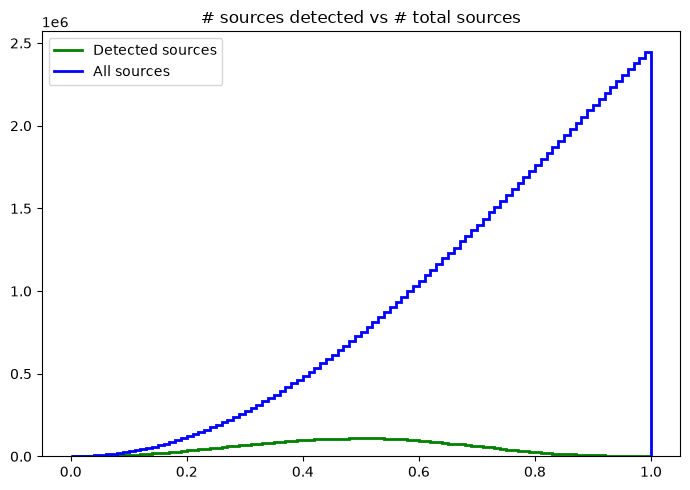

In [10]:
plt.figure(figsize= (7,5))
plt.stairs(n_sources_detected, z_edges, label='Detected sources', color='green', lw = 2)
plt.stairs(n_sources_all, z_edges, label='All sources', color='b', lw = 2)
plt.legend()
plt.title('# sources detected vs # total sources')
plt.tight_layout()
plt.show()

In [11]:
# Datafrom Petrecca & Botticelli et al. 2014 (note: they used 15 sq deg only and redshift bins of 0.05)
z_mid_pet = np.array([0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625, 0.675])
eff_pet = np.array([34.8, 77.3, 50.1, 47.1, 37.0, 37.3, 37.1, 20.6, 20.4, 15.2, 10.1, 7.1]) / 100

In [12]:
R_z = R_SFR(z_mid, R0=p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr)) # theoretical volumetric rate

In [13]:
print('fraction of sky covered by LSST opsim:', 18000 / 41253) #4 pi sr ~41253 sq deg
# I previously used 0.435 for the presentation.

fraction of sky covered by LSST opsim: 0.4363319031343175


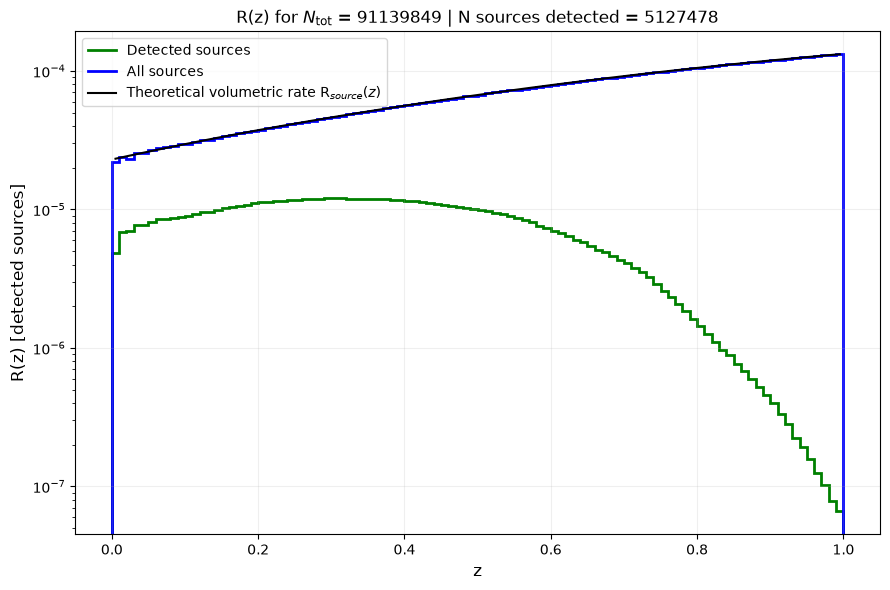

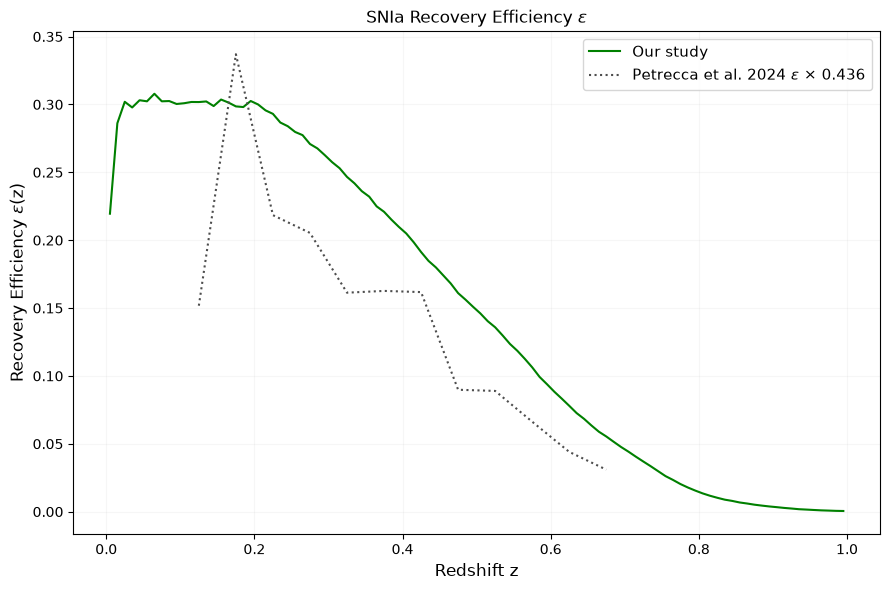

In [14]:
plt.figure(figsize=(9,6))
# you could use plt.plot instead of plt.stairs() if you prefer
plt.stairs(Rz_bin_counts * (1 + z_mid), z_edges, label='Detected sources', color='green', lw = 2)
plt.stairs(Rz_bin_counts_all * (1 + z_mid), z_edges, label='All sources', color='b', lw = 2)
plt.plot(z_mid, R_z, label='Theoretical volumetric rate R$_{{source}}(z)$', color='k', lw = 1.5)
plt.xlabel('z', fontsize = 12)
plt.yscale('log')
plt.ylabel('R(z) [detected sources]', fontsize = 12)
plt.legend()
plt.title(
    f'R(z) for $N_{{\\mathrm{{tot}}}}$ = {total_rows} | N sources detected = {total_detected}', fontsize = 12)
plt.grid(alpha = 0.2)
plt.tight_layout()
plt.show()

# recovery (det/sim) is not completeness (det/sim) is frac recovered by source extraction procedure
# note that we scale by 0.435 because roughly 18000 / 4 pi sr is covered by LSST obs plan
plt.figure(figsize=(9,6))
plt.plot(z_mid, Rz_bin_counts / Rz_bin_counts_all, color = 'g', label = 'Our study')
plt.plot(z_mid_pet, eff_pet * 0.436, ':', color = '0.3', label = 'Petrecca et al. 2024 $\\epsilon$ $\\times$ 0.436')
plt.title('SNIa Recovery Efficiency $\\epsilon$')
plt.xlabel('Redshift z', fontsize = 12)
plt.ylabel('Recovery Efficiency $\\epsilon$(z)', fontsize = 12)
plt.grid(alpha = 0.1)
plt.tight_layout()
plt.legend(fontsize = 11)

#### Check that generated Rz_simulated $\times$ (1+z) follows theoretical volumetric source rate R(z) i.e. ratio converges to 1.0

Text(0.5, 1.0, 'Ratio of simulated to theoretical volumetric rate \nN$_{tot}$ = 91139849 | N sources detected = 5127478')

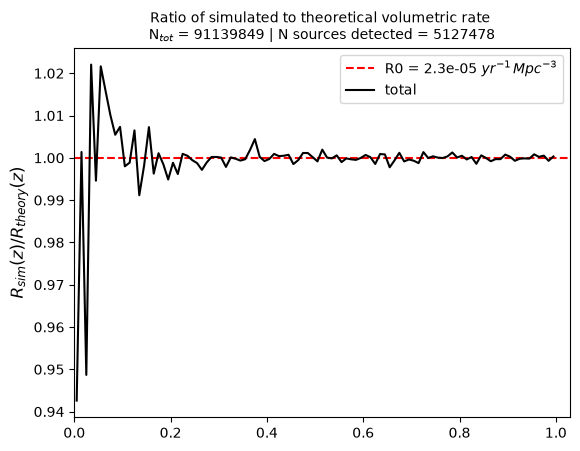

In [15]:
plt.axhline(1,color="r",linestyle="--",label="R0 = {:.1e} $yr^{{-1}}\\,Mpc^{{-3}}$".format(p_cosmology["R0"]["SN Ia"].to(u.Mpc**-3 / u.yr).value))
plt.plot(z_mid, Rz_bin_counts_all * (1+z_mid)/ R_z , color='k', linestyle = '-', label='total')
plt.ylabel(f'${{R_{{sim}}(z)}} / {{R_{{theory}}(z)}}$', fontsize = 12)

plt.xlim(0, 1.03)
plt.legend()
# plt.title(f'Ratio of rates =  rate * (1+z)/ R_z (theory) \n for N_tot = {total_rows}, # sources detected = {total_detected}', fontsize = 10)
plt.title(
    f'Ratio of simulated to theoretical volumetric rate \n'
    'N$_{tot}$' f' = {total_rows} | N sources detected = {total_detected}',
    fontsize=10
)

In [16]:
n_alerts_total = (np.sum(data["n_lsstu"])+ np.sum(data["n_lsstg"])+ np.sum(data["n_lsstr"]) + np.sum(data["n_lssti"])+ np.sum(data["n_lsstz"])+ np.sum(data["n_lssty"]))
alerts_per_night = n_alerts_total / 3650 #we use 10 years (obs time), not 10 years + 100d (generated SNIa t0 range)
detected_sources_per_night = np.sum(n_sources_detected) / 3650
total_sources_per_night = np.sum(n_sources_all) / 3650

In [17]:
print(f'SNIa detected per night, {detected_sources_per_night:.2f} out of {total_sources_per_night:.2f}')
print(f'SNIa alerts per night {alerts_per_night:.2f}')

SNIa detected per night, 1404.79 out of 24969.82
SNIa alerts per night 19891.52


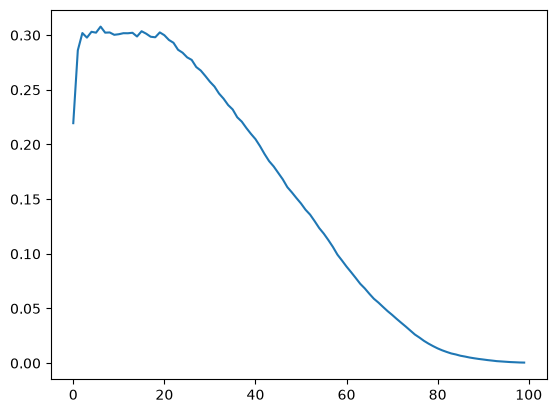

In [18]:
plt.plot(n_sources_detected / n_sources_all)
# same as dividing rates because both have common denominator of volumes

## With bands
I have an alternate file here where the by-band data are arrays of len 100 instead of floats. Because I did these in the last day, most of the following were all quickly created using GPT.

In [19]:
total_detections_per_bin = (data["n_lsstu"]+ data["n_lsstg"]+ data["n_lsstr"]+ data["n_lssti"]+ data["n_lsstz"]+ data["n_lssty"])

In [20]:
total_detections = total_detections_per_bin.sum()
total_detections

np.int64(72604050)

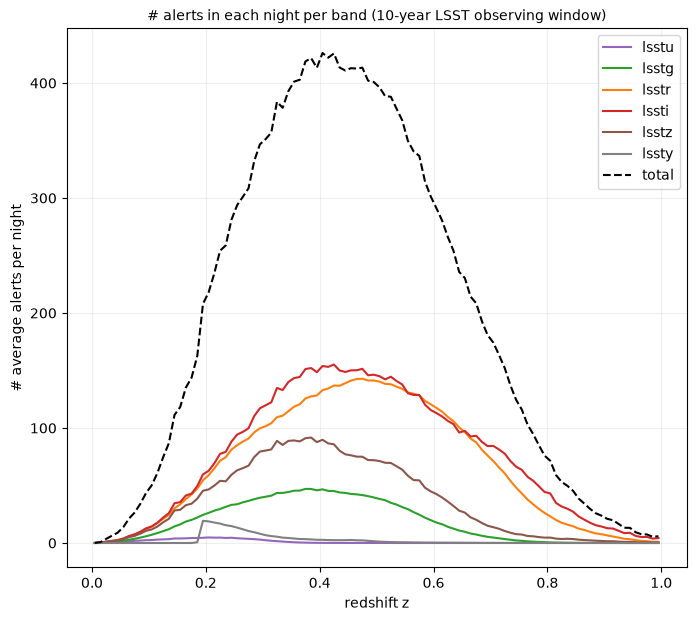

In [21]:
plt.figure(figsize=(8, 7))

bands = ["n_lsstu", "n_lsstg", "n_lsstr", "n_lssti", "n_lsstz", "n_lssty"]

for band, color in zip(bands, lsst_colors):
    label = band.replace("n_", "")
    plt.plot(z_mid,data[band] / 3650, color=color,label=label)

plt.plot(z_mid,total_detections_per_bin / 3650,color="k", linestyle = '--', label="total")

plt.title("# alerts in each night per band (10-year LSST observing window)", fontsize=10)
plt.xlabel("redshift z")
plt.ylabel("# average alerts per night")

plt.grid(alpha=0.2)
plt.legend()

plt.show()

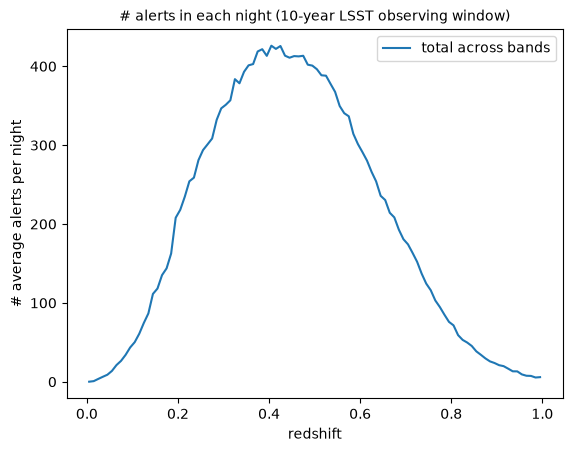

In [22]:
plt.plot(z_mid, total_detections_per_bin/3650, label = 'total across bands')
plt.title('# alerts in each night (10-year LSST observing window)', fontsize = 10)
plt.xlabel('redshift')
plt.ylabel('# average alerts per night')
plt.legend()

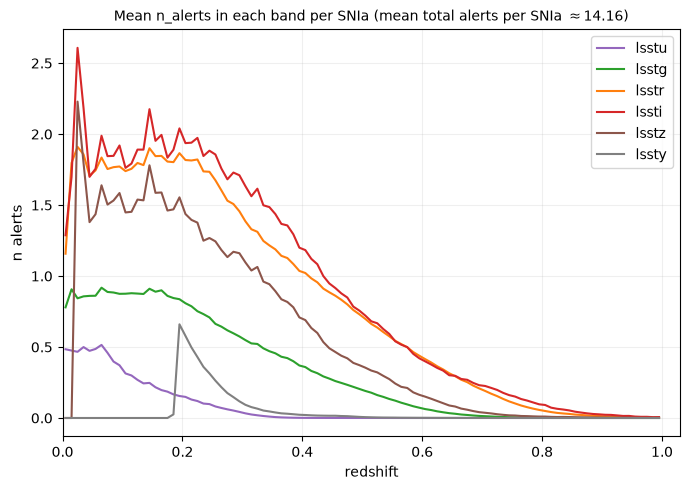

In [23]:
plt.figure(figsize=(7, 5))

# Per-band detection rates
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

for band, color in zip(bands, lsst_colors):

    band_rate = (
        data[f"n_{band}"]
        / shell_volumes
        / 10
    )

    plt.plot(
        z_mid,
        band_rate * (1 + z_mid) / R_z,
        color=color,
        linestyle="-",
        linewidth=1.5,
        label=band
    )

plt.xlim(0, 1.03)

plt.xlabel("redshift")
plt.ylabel("n alerts",fontsize=11)

plt.title(
    f"Mean n_alerts in each band per SNIa "
    "(mean total alerts per SNIa $\\approx$14.16)",
    fontsize=10
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Visualising parameter distribution of generated vs detected SNIa
#### with new aggregation script <code>aggregate_by_param.py</code> which creates aggregated_results_new.npz
The .npz file here contains both by band data and also binned in 100 values of x1 and c.\
We only use this .npz file solely for visualising the distribution of different parameters.

In [24]:
data = np.load("results_5/aggregated_results_new.npz")

In [25]:
parameters = [
    "z",
    "x1",
    "c",
    "t0",
    "magabs",
    "magobs",
    "ra",
    "dec",
]

labels = {
    "z": r"$z$",
    "x1": r"$x_1$",
    "c": r"$c$",
    "t0": r"$t_0$",
    "magabs": r"magabs",
    "magobs": r"magobs",
    "ra": "ra (deg)",
    "dec": "dec (deg)",
}

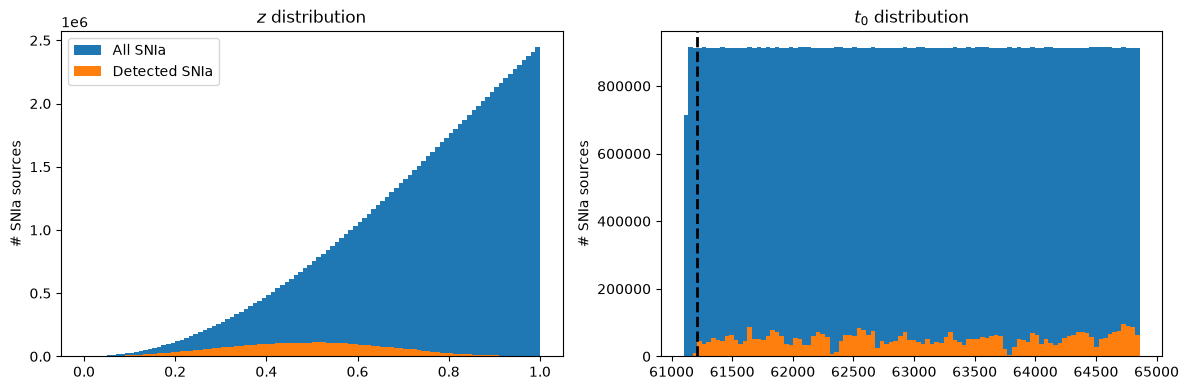

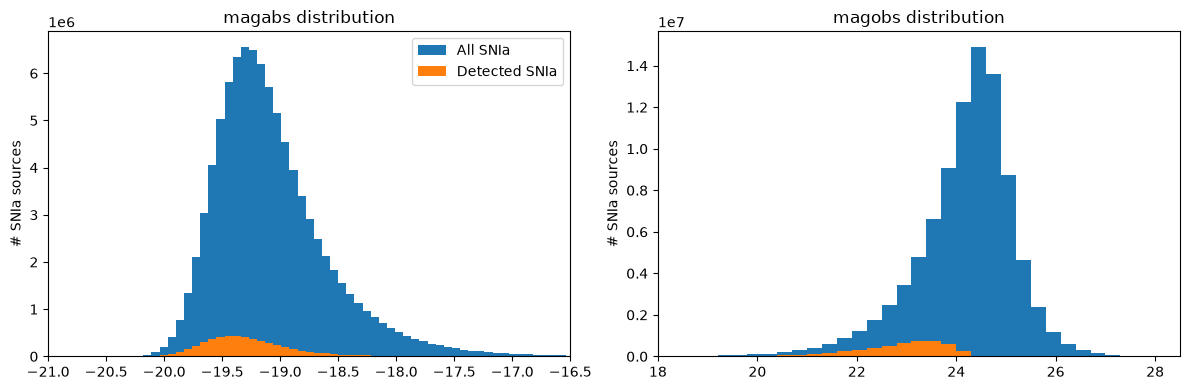

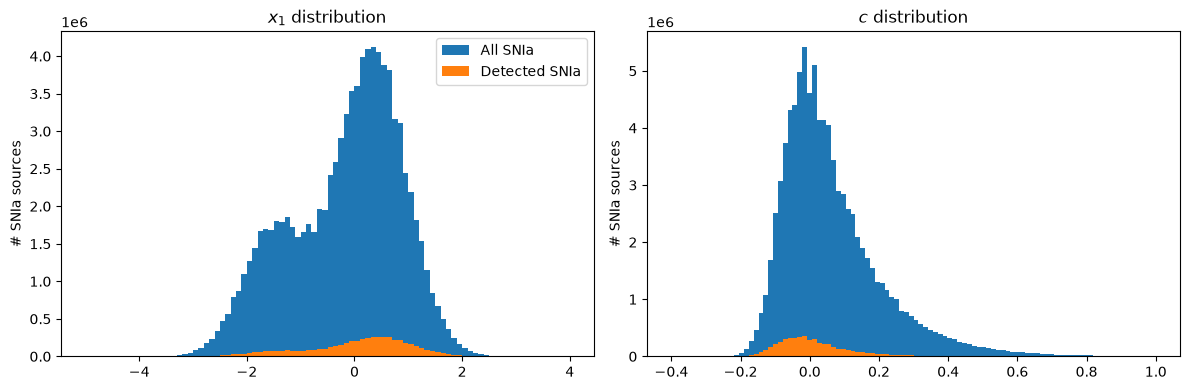

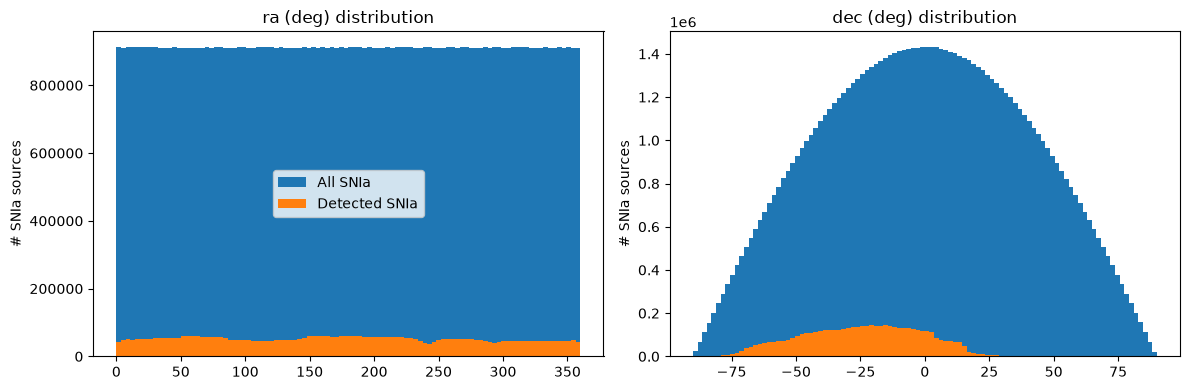

In [26]:
import numpy as np
import matplotlib.pyplot as plt

xlims = {
    "magabs": (-21, -16.5),
    "magobs": (18, 28.5),
}

# ------------------------------------------------------------
# Parameter pairs for the four figures
# ------------------------------------------------------------

figure_pairs = [
    ("z", "t0"),
    ("magabs", "magobs"),
    ("x1", "c"),
    ("ra", "dec"),
]


# ------------------------------------------------------------
# Make four separate figures
# ------------------------------------------------------------
tmin_lsst = 61208.20243056 #in MJD. The values on skysurvey tutorial is wrong.

for param1, param2 in figure_pairs:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4),
    )

    for ax, param in zip(axes, [param1, param2]):

        edges = data[f"{param}_edges"]

        all_counts = data[f"n_{param}_all"]

        detected_counts = data[f"n_{param}_detected"]

        # Filled stairs: all sources
        ax.stairs(
            all_counts,
            edges,
            fill=True,
            color="tab:blue",
            alpha=1,
            label="All SNIa",
        )

        # Filled stairs: detected sources
        ax.stairs(
            detected_counts,
            edges,
            fill=True,
            color="tab:orange",
            alpha=1,
            label="Detected SNIa",
        )

        if param == "t0":
            ax.axvline(
                tmin_lsst,
                color="k",
                linestyle="--",
                linewidth=2,
                label="Survey start",
            )

        # ax.set_xlabel(labels[param])
        if param in xlims:
            ax.set_xlim(xlims[param])

        ax.set_ylabel("# SNIa sources")
        ax.set_title(f"{labels[param]} distribution")

    # axes[1].legend(loc = 'center right', fontsize = 9)
    axes[0].legend()
    plt.tight_layout()
    plt.show()